# Customer Churn Prediction

## 06 - Model Evaluation & Business Impact

This notebook evaluates the final Random Forest model from both technical and business perspectives.

Evaluation includes:

- Classification Metrics
- Confusion Matrix
- ROC-AUC Analysis
- Feature Importance
- SHAP Explainability
- Risk Segmentation
- Business Impact Assessment

The objective is to determine not only how accurately the model predicts churn, but also how the insights can be translated into actionable business decisions.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [3]:
BASE_DIR = Path().resolve().parent

file_path = BASE_DIR / "Data" / "processed" / "feature_engineered_churn.csv"

df = pd.read_csv(file_path)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,IsNewCustomer,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,HighMonthlyCharges,TenureGroup_1-2yr,TenureGroup_2-4yr,TenureGroup_4+yr,CustomerValue,TenureGroup_1-2yr.1,TenureGroup_2-4yr.1,TenureGroup_4+yr.1,AvgMonthlySpend,Churn
0,0,1,29.85,29.85,1,False,True,False,False,True,...,0,False,False,False,29.85,False,False,False,14.925000,0
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,0,False,True,False,1936.30,False,True,False,53.985714,0
2,0,2,53.85,108.15,1,True,False,False,True,False,...,0,False,False,False,107.70,False,False,False,36.050000,1
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,0,False,True,False,1903.50,False,True,False,40.016304,0
4,0,2,70.70,151.65,1,False,False,False,True,False,...,1,False,False,False,141.40,False,False,False,50.550000,1


In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
best_model = joblib.load("../models/best_random_forest.pkl")

best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [6]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

## Classification Report

The classification report provides a detailed breakdown of model performance across both churn and non-churn customers.

Key metrics include:

- Precision
- Recall
- F1-Score

Particular attention is paid to churn recall because failing to identify customers who are likely to leave can result in direct revenue loss.

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.76      0.82      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



### Key Insight

The model achieves an overall **accuracy of 76%** and demonstrates a strong ability to distinguish between churning and non-churning customers.

For the **churn class**, the model achieves a **recall of 78%**, meaning it successfully identifies nearly **four out of every five customers** who are likely to leave. This is particularly valuable from a business perspective because missed churners represent lost revenue and missed retention opportunities.

The **precision of 54%** indicates that some customers predicted to churn will ultimately remain with the company. However, in customer retention strategies, this trade-off is often acceptable because the cost of offering targeted retention incentives is typically lower than the cost of losing valuable customers.

Overall, the model provides a reliable foundation for proactive customer retention, enabling the business to identify high-risk customers early and prioritize intervention efforts effectively.

## ROC-AUC Analysis

ROC-AUC measures the model's ability to distinguish between churn and non-churn customers across all possible classification thresholds.

Values closer to 1 indicate stronger discriminatory power.

In [8]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8430597535456871


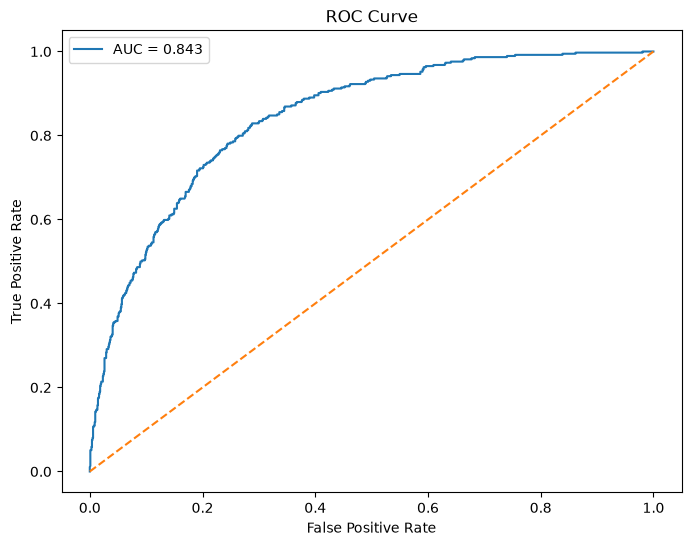

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### ROC-AUC Interpretation

The model achieved a ROC-AUC score of 0.843, indicating strong discriminatory power between customers who churn and those who remain.

In practical terms, the model has an 84.3% probability of ranking a randomly selected churning customer higher in churn risk than a randomly selected non-churning customer.

This suggests that the model captures meaningful behavioral patterns associated with churn and can reliably support customer retention decision-making.


## Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of model predictions.

It highlights:

- Correctly identified retained customers
- Correctly identified churned customers
- False alarms
- Missed churners

This helps assess the practical effectiveness of the model.

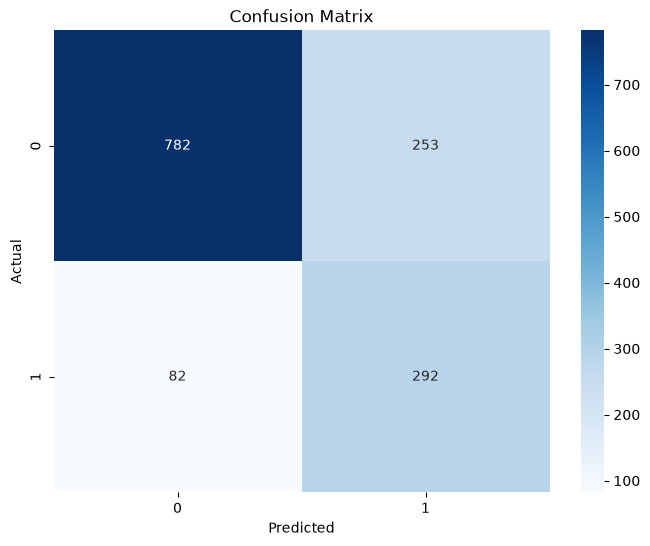

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [11]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

confusion_summary = pd.DataFrame({
    "Metric": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Count": [
        tn,
        fp,
        fn,
        tp
    ]
})

confusion_summary

,Metric,Count
0,True Negatives,782
1,False Positives,253
2,False Negatives,82
3,True Positives,292


### Business Interpretation

The model correctly identified:

- 782 retained customers
- 292 churned customers

The model missed only 82 churned customers while incorrectly flagging 2253 retained customers as churn risks.

From a business perspective, false positives are generally less costly than missed churners because retention interventions are typically cheaper than customer acquisition.

This indicates the model is effective for proactive retention campaigns.

## Feature Importance

Random Forest provides feature importance scores that indicate which variables contribute most to the model's predictions.

Higher scores indicate greater influence on churn prediction.

In [15]:
print(type(best_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [16]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,tenure,0.111555
26,Contract_Two year,0.087311
3,TotalCharges,0.080610
35,CustomerValue,0.080271
39,AvgMonthlySpend,0.074608
2,MonthlyCharges,0.072360
11,InternetService_Fiber optic,0.070426
29,PaymentMethod_Electronic check,0.040544
25,Contract_One year,0.031449
38,TenureGroup_4+yr.1,0.030975


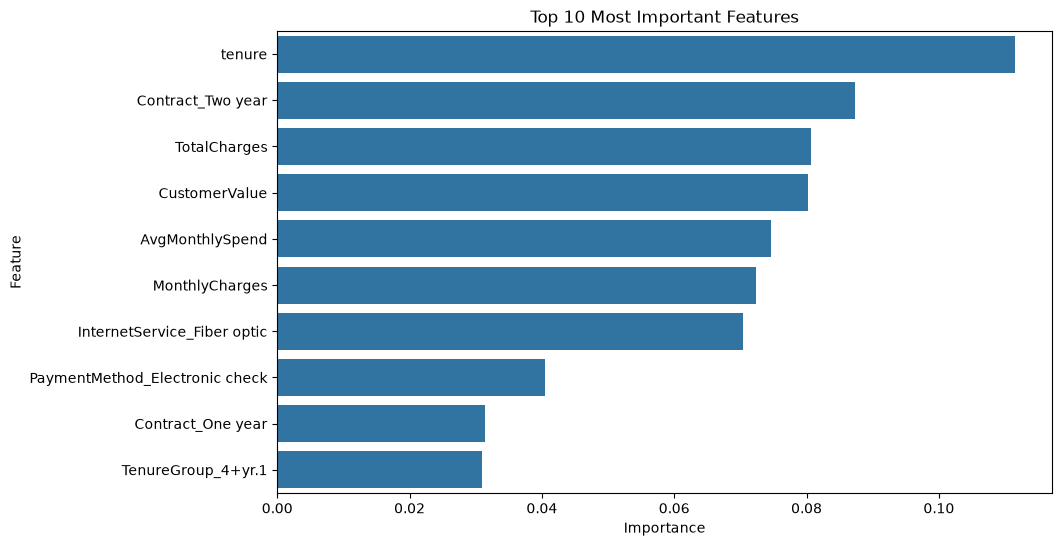

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.show()

### Feature Importance Analysis

The feature importance analysis indicates that **customer tenure** is the strongest predictor of churn, highlighting that the length of a customer's relationship with the company plays a critical role in retention. Customers with shorter tenures are generally more susceptible to leaving than long-term customers.

**Contract type** is another major driver of churn prediction. The prominence of **Two-Year** and **One-Year** contract features suggests that customers with long-term commitments are significantly less likely to churn than those on month-to-month plans.

Financial variables, including **Total Charges**, **Average Monthly Spend**, **Customer Value**, and **Monthly Charges**, also rank among the most influential predictors. This indicates that spending behavior and customer value are closely associated with churn risk and should be considered when designing retention strategies.

Service-related features such as **Fiber Optic Internet**, **Tech Support**, and **Online Security**, together with **Electronic Check** as a payment method, further contribute to the model's predictions. These features suggest that both service experience and payment preferences influence customer retention.

#### Business Implications

The findings suggest that customer retention efforts should prioritize:

- **New and recently acquired customers**, who are more likely to churn.
- **Customers on month-to-month contracts**, as they have fewer long-term commitments.
- **High-value and high-spending customers**, whose loss would have a greater business impact.
- **Fiber Optic subscribers**, who may require additional attention to improve satisfaction.
- **Customers paying via Electronic Check**, as this payment method is associated with a higher likelihood of churn.
- **Customers without Tech Support or Online Security services**, who may benefit from targeted service bundles or promotional offers.

By focusing retention initiatives on these customer segments, the business can reduce churn more effectively and maximize the return on customer retention investments.

## Model Explainability with SHAP

Feature importance identifies influential variables, but **SHAP (SHapley Additive exPlanations)** explains how individual features contribute to predictions.

This provides transparency into the model's decision-making process and validates whether predictions align with business intuition.

Features appearing at the top of the chart have the strongest influence on the model's decision-making process, while the color scale indicates whether high or low feature values increase churn risk.

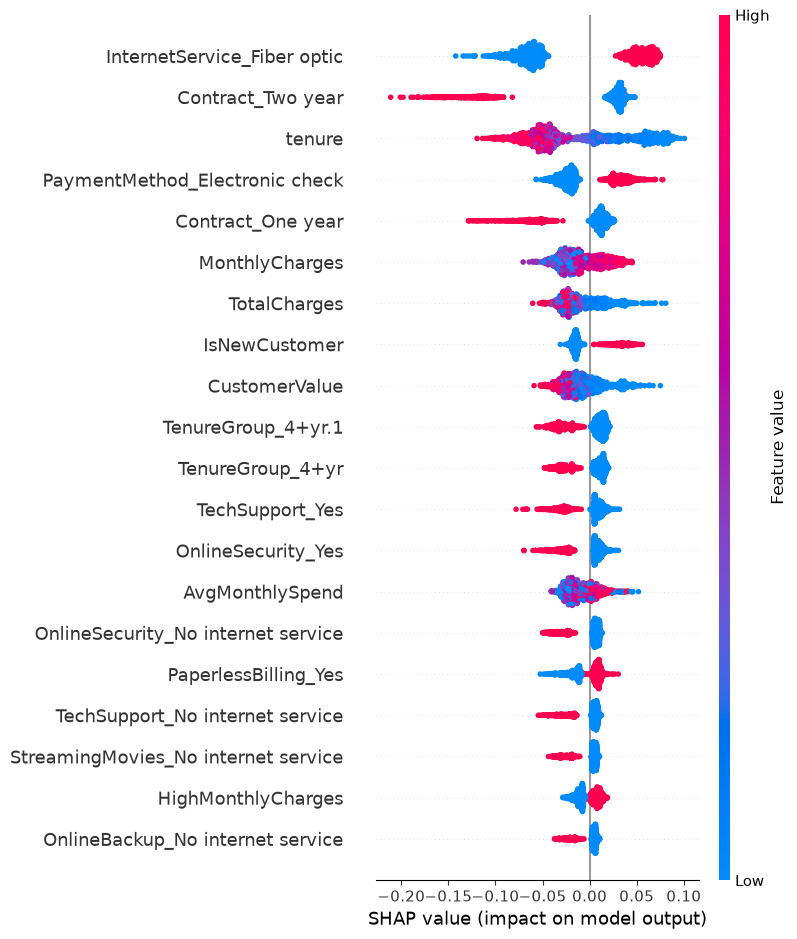

In [18]:
# The loaded model is already a RandomForestClassifier
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Summary plot for the positive (churn) class
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

### SHAP Analysis Interpretation

The SHAP analysis provides a deeper understanding of how individual features influence churn predictions.

Consistent with the feature importance results, tenure, contract type, spending behavior, and internet service characteristics exert the strongest influence on churn risk. Customers with shorter tenure periods, higher monthly spending, month-to-month contract structures, and Fiber Optic subscriptions are more likely to be classified as churn risks.

The SHAP results reinforce the conclusions drawn from the exploratory analysis and provide additional confidence that the model is learning meaningful business relationships rather than random patterns within the data.

These insights can be used to design targeted retention strategies for the most vulnerable customer segments.

## Customer Risk Segmentation

Predicting whether a customer will churn is valuable, but businesses often need a more practical way to prioritize intervention efforts.

To support decision-making, customers are grouped into risk categories based on their predicted probability of churn:

- **Low Risk:** Less than 30% predicted probability of churn
- **Medium Risk:** Between 30% and 60% predicted probability of churn
- **High Risk:** Greater than 60% predicted probability of churn

This segmentation enables the business to allocate retention resources more efficiently by focusing attention on customers most likely to leave.

In [19]:
df_eval = X_test.copy()

df_eval["Churn_Prob"] = y_prob

def risk_level(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Medium Risk"
    else:
        return "High Risk"

df_eval["Risk_Level"] = df_eval["Churn_Prob"].apply(risk_level)

risk_counts = df_eval["Risk_Level"].value_counts()

risk_summary = pd.DataFrame({
    "Count": risk_counts,
    "Percentage": round((risk_counts / len(df_eval)) * 100, 2)
})

risk_summary

,Count,Percentage
Risk_Level,,
Low Risk,643,45.64
High Risk,433,30.73
Medium Risk,333,23.63


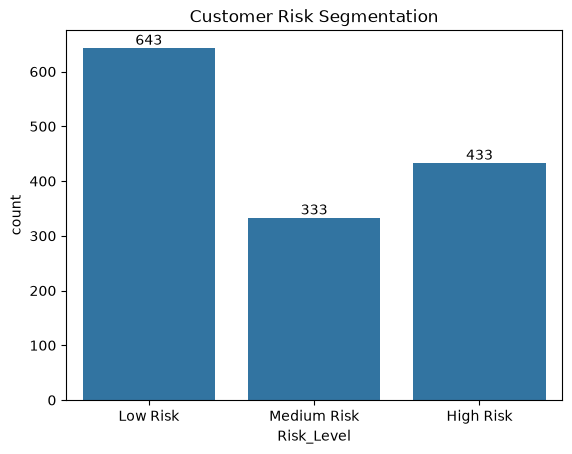

In [20]:
ax = sns.countplot(
    data=df_eval,
    x="Risk_Level",
    order=["Low Risk","Medium Risk","High Risk"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Risk Segmentation")

plt.show()

### Risk Segmentation Insights

The model classified **45.6%** of customers as **Low Risk**, **23.6%** as **Medium Risk**, and **30.7%** as **High Risk**.

The **High-Risk** segment represents nearly one-third of the evaluated customer base, highlighting a significant group of customers who may be at risk of leaving. These customers should be prioritized for targeted retention strategies such as personalized offers, loyalty incentives, proactive customer support, and service quality reviews.

The **Medium-Risk** segment presents an opportunity for early intervention. Targeted communication, product recommendations, and enhanced customer engagement initiatives may help strengthen customer relationships and reduce the likelihood of future churn.

Meanwhile, the **Low-Risk** segment appears relatively stable and requires routine customer relationship management to maintain satisfaction and loyalty. Although these customers are less likely to churn, continuous monitoring and consistent service quality remain important to sustain long-term retention.

## Business Impact Analysis

Building an accurate churn prediction model is only valuable if it can create measurable business outcomes.

In this section, we estimate the potential financial impact of using the model to proactively identify high-risk customers and target them with retention campaigns.

The objective is to compare the estimated cost of customer loss against the cost of proactive retention efforts and quantify the potential savings generated by the model.

In [21]:
cost_churn = 100
cost_retention = 20

high_risk = df_eval[df_eval["Churn_Prob"] > 0.6]

loss_without_model = len(high_risk) * cost_churn

cost_with_model = len(high_risk) * cost_retention

savings = loss_without_model - cost_with_model

print("Estimated Business Savings:", savings)

Estimated Business Savings: 34640


## Business Impact Interpretation

Using the model to identify and target high-risk customers could generate an estimated business value of approximately **$34,640** under the assumptions used in this analysis.

The estimate compares the potential cost of customer churn against the cost of executing retention interventions for customers identified as high risk.

### Assumptions

* Cost of losing a customer = $100
* Cost of retention intervention = $20
* Customers with churn probability above 60% are classified as high risk

Although the figures are illustrative, the analysis demonstrates how predictive analytics can move beyond forecasting and directly support revenue preservation strategies.

The results highlight the potential financial benefits of focusing retention resources on customers most likely to churn.


## Strategic Recommendations

Based on the exploratory analysis, machine learning results, feature importance rankings, and SHAP explanations, the following actions are recommended:

1. Prioritize retention efforts for newly acquired customers, as shorter tenure is the strongest predictor of churn.
2. Encourage customers to transition from month-to-month contracts to longer-term agreements through incentives and loyalty programs.
3. Investigate customer satisfaction among Fiber Optic subscribers, as this segment consistently demonstrates elevated churn risk.
4. Review pricing structures and value propositions for customers with high monthly spending to reduce price-related attrition.
5. Develop targeted retention campaigns for customers classified as High Risk by the model.
6. Monitor customers using Electronic Check payment methods, as this group exhibits higher churn tendencies than other payment segments.

By focusing on these customer groups, the organization can reduce churn, improve customer lifetime value, and maximize the return on retention investments.
